### LASSO Optimisation: Our aim is to minimise $\frac{||y - X \beta||^2}{2n} + \lambda \sum_{j =1}^{p}|\beta_j|$ for $\beta$, but since $|\beta|$ is not differentiable so we will coordinate desent method.

### In coordinate desent method we have S(a, $\lambda$) =  a- $\lambda$ for a > $\lambda$ , 0 for |a| $\leq \lambda$, a + $\lambda$ for a < -$\lambda$ 

In [53]:
np.random.seed(0)

n = 100
p = 5

X = np.random.randn(n, p)

true_beta = np.array([3, 1.5, 0, 0, 2])

y = X @ true_beta + np.random.randn(n)


In [54]:
size_of_sol = 5
beta_bbo = np.zeros(size_of_sol)
s_bbo = np.zeros(size_of_sol)
number_iterations = 1000
lambda_bbo = 5.0
tol = 1e-2
for i in range(number_iterations):
    old_beta_bbo = beta_bbo
    #print(beta_bbo,i)
    for j in range(size_of_sol):
        if (beta_bbo[j]==0):
            s_bbo[j] = np.random.uniform(-1,1)
        elif (beta_bbo[j]<0):
            s_bbo[j] = -1
        else:
            s_bbo[j] = 1
    beta_bbo = np.linalg.inv(X.T@X)@(X.T @ y - lambda_bbo*s_bbo)
    if (np.linalg.norm(beta_bbo-old_beta_bbo)<tol):
        break
print(beta_bbo,i)

[ 2.9861509   1.52311015  0.16840625 -0.03622197  1.871356  ] 999


In [55]:
# Implimenting using Sklearn
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = Lasso(alpha=0.1)
model.fit(X_scaled, y)
model.coef_

array([2.92786602, 1.39481005, 0.09401003, 0.        , 1.78894043])

## Ridge

In [13]:
import numpy as np

def ridge_regression(X, y, lam):
    p = X.shape[1]
    I = np.eye(p)
    beta = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y

    return beta

In [14]:
np.random.seed(0)
n = 100
p = 5

X_ridge = np.random.randn(n, p)

true_beta_ridge = np.array([3, 1.5, 0, 0, 2])

y_ridge = X_ridge @ true_beta_ridge + np.random.randn(n)

In [15]:
beta_est = ridge_regression(X, y, lam=0.5)

print("Estimated coefficients:", beta_est)

Estimated coefficients: [3.02833086e+00 1.57021352e+00 2.23773826e-01 3.92076954e-04
 1.90587274e+00]


In [17]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

np.random.seed(0)

n = 100
p = 5
y_ridge = X_ridge @ true_beta_ridge + np.random.randn(n)

scaler = StandardScaler()
X_scaled_ridge = scaler.fit_transform(X)

model = Ridge(alpha=0.5)
model.fit(X_scaled_ridge, y_ridge)

print("Estimated coefficients:", model.coef_)
y_pred_ridge = model.predict(X_scaled_ridge)

Estimated coefficients: [ 3.02734614  1.52342128 -0.03566815 -0.11159782  2.16457348]


## Elastic Net

In [68]:
beta_elast = np.zeros(5)
s = np.zeros(5)
numb_itr = 1000
alpha = 0.0
lambd = 1
tol = 1e-5
for i in range(numb_itr):
    old_beta_elast = beta_elast
    for j in range(len(s)):
        if beta_elast[j] == 0:
            s[j] = np.random.uniform(-1, 1)
        elif beta_elast[j] < 0:
            s[j] == -1
        else: 
            s[j] == 1
    beta_elast = np.linalg.inv(X.T@X - lambd*(1-alpha)*np.eye(5))@(X.T@y - lambd*alpha*s)
    if np.linalg.norm(old_beta_elast-beta_elast) < tol:
        break
beta_elast

array([ 3.079287  ,  1.59589107,  0.23335454, -0.00809733,  1.9390607 ])

In [70]:
def elastic_net(x,y,alpha,lamb=1.0,tol=1e-5,):
    beta_elast = np.zeros(x.shape[1])
    s = np.zeros(x.shape[1])
    numb_itr = 1000
    for i in range(numb_itr):
        old_beta_elast = beta_elast
        for j in range(len(s)):
            if beta_elast[j] == 0:
                s[j] = np.random.uniform(-1, 1)
            elif beta_elast[j] < 0:
                s[j] == -1
            else: 
                s[j] == 1
        beta_elast = np.linalg.inv(X.T@X - lambd*(1-alpha)*np.eye(5))@(X.T@y - lambd*alpha*s)
        if np.linalg.norm(old_beta_elast-beta_elast) < tol:
            break
    return beta_elast

In [79]:
lambda_list = [1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
alpha = 0.5
beta_different_lambd = []
for i in range(len(lambda_list)):
    beta_different_lambd.append(elastic_net(x=X, y=y,alpha=alpha,lamb= lambda_list[i]))

In [92]:
beta_different_lambd=np.asarray(beta_different_lambd)

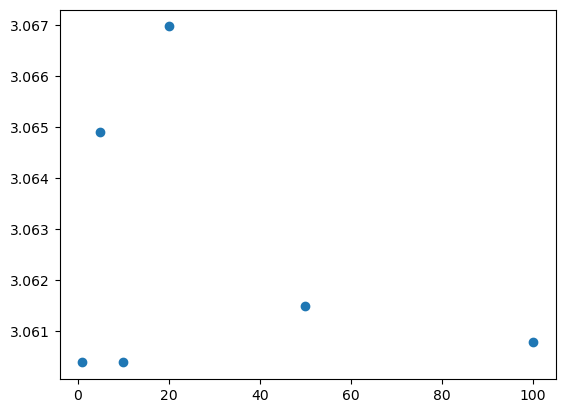

In [94]:
import matplotlib.pyplot as plt
plt.scatter(lambda_list, beta_different_lambd[:,0])

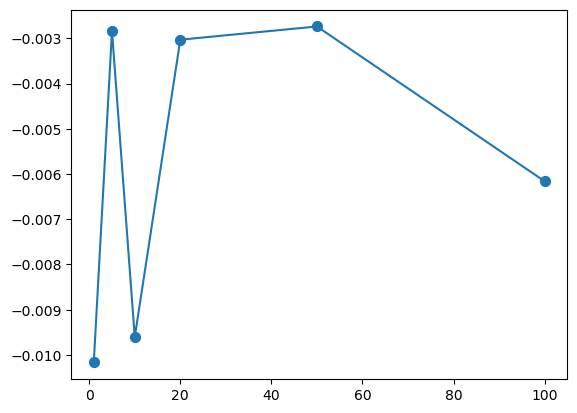

In [103]:
import matplotlib.pyplot as plt
plt.plot(lambda_list, beta_different_lambd[:,3])
plt.scatter(lambda_list, beta_different_lambd[:,3],s=50)